In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping,ReduceLROnPlateau


import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kartik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [89]:
data = pd.read_csv("spam_ham_dataset.csv")

In [90]:
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [91]:
data.shape

(5171, 4)

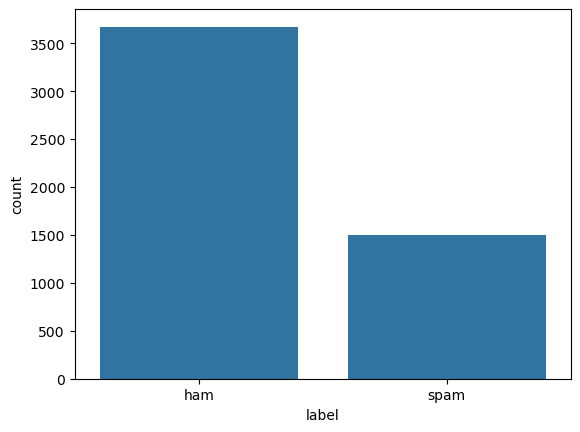

In [92]:
sns.countplot(x="label",data=data)
plt.show()

In [1]:
#Balance the Dataset

([<matplotlib.axis.XTick at 0x19cd009fc50>,
 [Text(0, 0, 'Ham (Not Spam)'), Text(1, 0, 'Spam')])

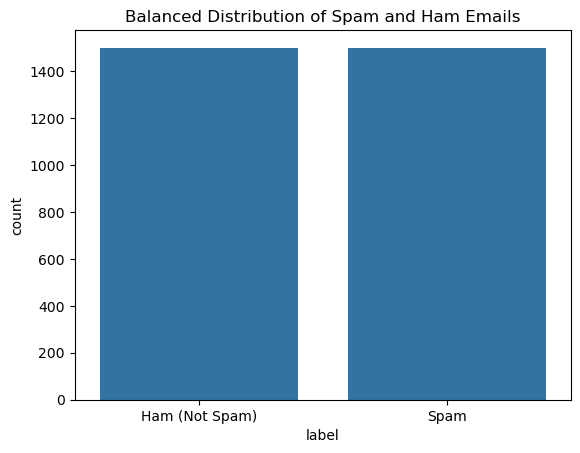

In [93]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']
ham_msg_balanced = ham_msg.sample(n = len(spam_msg),random_state=42)
balanced_data = pd.concat([ham_msg_balanced,spam_msg]).reset_index(drop=True)

sns.countplot(x='label', data = balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks = [0,1],labels = ['Ham (Not Spam)','Spam'])


In [97]:
balanced_data['text'] = balanced_data['text'].str.replace('subject','')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject conoco big cowboy\r\ndarren \r\ni m ...,0
1,2982,ham,Subject feb 01 prod sale to teco gas processi...,0
2,2711,ham,Subject california energy crisis\r\ncalifornia...,0
3,3116,ham,Subject re nom actual volume for april 23 rd...,0
4,1314,ham,Subject eastrans nomination changes effective ...,0


In [98]:
# remove Punctuation
punctuation_list = string.punctuation

def remove_punctuation(text):
    temp = str.maketrans('','',punctuation_list)
    return text.translate(temp)


balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuation(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject conoco big cowboy\r\ndarren \r\ni m ...,0
1,2982,ham,Subject feb 01 prod sale to teco gas processi...,0
2,2711,ham,Subject california energy crisis\r\ncalifornia...,0
3,3116,ham,Subject re nom actual volume for april 23 rd...,0
4,1314,ham,Subject eastrans nomination changes effective ...,0


In [99]:
#Remove StopWords
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)
    return output

In [100]:
balanced_data['text'] = balanced_data['text'].apply(lambda text : remove_stopwords(text)) 
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,subject conoco big cowboy darren sure help kno...,0
1,2982,ham,subject feb 01 prod sale teco gas processing s...,0
2,2711,ham,subject california energy crisis california  ...,0
3,3116,ham,subject nom actual volume april 23 rd agree ei...,0
4,1314,ham,subject eastrans nomination changes effective ...,0


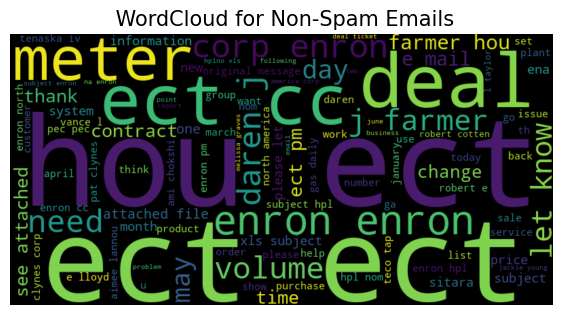

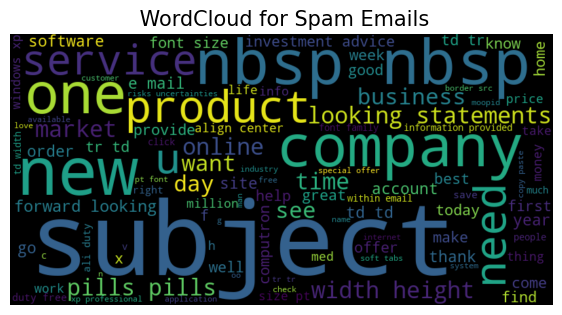

In [101]:
# Visualization Word Cloud
def plot_word_cloud(data,typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color = 'black', max_words = 100, width = 800, height=400).generate(email_corpus)
    plt.figure(figsize=(7,7))
    plt.imshow(wc,interpolation='bilinear')
    plt.title(f' WordCloud for {typ} Emails' , fontsize = 15)
    plt.axis("off")
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

In [30]:
# Tokenization and Padding


In [120]:
train_X,test_X,train_Y,test_Y = train_test_split(balanced_data['text'],balanced_data['label'],test_size=0.2,random_state=42)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)
max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen = max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen = max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [39]:
# Define The Model

In [121]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1,output_dim = 32, input_length = max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])


model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)             │ (None, 100, 32)             │       1,274,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_21 (LSTM)                       │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
# Train The Model

In [122]:
print(type(train_sequences))
print(type(test_sequences))
print(type(train_Y))
print(type(test_Y))
print(train_sequences[:2])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
[[    2   306    48   417   367 11307   107   285    54    79   226   852
    232   604   675    25    71   923    26 17860 17861   752   126 11308
    724 17862 17863 17864  3304 11309   191 11310   972   438  1948  1768
   2314 17865 11311   952   104    40   122  1227   626    26   126    16
  17866 17867     6    76 17868   226     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0]
 [    2   713   241   523  6799   279  2032   893  1191    14  8399  1656
   3732   714  5237   537   451  2417  2032  3504  2128   228   283  1480
   3504  5895   451  2417  4753 17869 17870   973 11312 17871   171 11313
   1295  2315 11313  1890   663   283  

In [146]:
es = EarlyStopping(patience = 3, monitor = 'val_accuracy',restore_best_weights=True)
lr = ReduceLROnPlateau (patience=2, monitor='val_loss',factor=0.5,verbose=0)
history = model.fit(
    train_sequences,train_Y,
    validation_data = (test_sequences,test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr,es]
)

model.summary()

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9850 - loss: 0.0768 - val_accuracy: 0.9650 - val_loss: 0.1481 - learning_rate: 7.8125e-06
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9850 - loss: 0.0768 - val_accuracy: 0.9650 - val_loss: 0.1482 - learning_rate: 7.8125e-06
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9850 - loss: 0.0767 - val_accuracy: 0.9650 - val_loss: 0.1482 - learning_rate: 7.8125e-06
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9850 - loss: 0.0767 - val_accuracy: 0.9650 - val_loss: 0.1483 - learning_rate: 3.9063e-06


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)             │ (None, 100, 32)             │       1,274,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_21 (LSTM)                       │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,835,877 (14.63 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,557,252 (9.76 MB)

In [147]:
history.history['accuracy']
history.history['val_accuracy']
history.history['loss']
history.history['val_loss']

[0.14810720086097717,
 0.14816364645957947,
 0.1482270061969757,
 0.148257777094841]

In [148]:
test_loss,test_accuracy = model.evaluate(test_sequences,test_Y)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9650 - loss: 0.1481


In [149]:
print('test Loss : ', test_loss)

test Loss :  0.14810720086097717


In [150]:
print('Test Accuracy : ', test_accuracy)

Test Accuracy :  0.9649999737739563


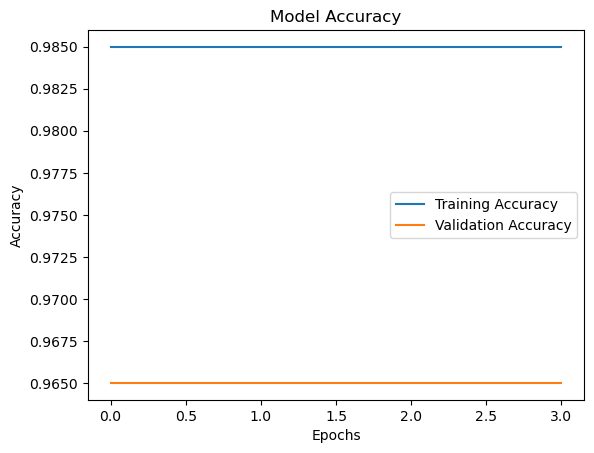

In [151]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()